# Simulating a 3D balanced SSFP acquisition

[`01_build.ipynb`](01_build.ipynb) writes two protocols -- a representative `192 x 192 x 16`
acquisition and a reduced one at the **same TR** -- each as a continuous and an interrupted
segmented file. It asserts that they are balanced, which is a statement about gradient waveforms.

**It is not a statement that the acquisition produces the image it is supposed to.** This notebook
answers the questions a waveform check cannot:

```text
1. what preparation should this protocol use, and why not the other one?
2. what did 01 actually write?
3. does the continuous acquisition reconstruct into the right volume?
4. what does interrupted segmentation change?
5. does it behave like bSSFP at all?
6. what remains a protocol choice?
```

Everything simulated here is a file `01` wrote. The reduced protocol is the one that is affordable
to simulate; it shares the representative protocol's preparation, phase cycle, view order,
segmentation rule and TR, and `01` writes it from the same functions so the relationship is
inspectable rather than asserted.

In [1]:
import os
import sys

#: MRzero's inner loop takes every core it is offered.  Hold it to four, before torch is imported.
SIM_THREADS = 4
for _var in ('OMP_NUM_THREADS', 'MKL_NUM_THREADS', 'RAYON_NUM_THREADS',
             'OPENBLAS_NUM_THREADS', 'NUMEXPR_NUM_THREADS'):
    os.environ[_var] = str(SIM_THREADS)

import contextlib
import os as _os
import warnings
from pathlib import Path

#: tqdm's auto-selector warns when ipywidgets is absent, which is an environment notice and has
#: nothing to do with this notebook.  It fires on whichever import first pulls in `tqdm.auto` --
#: pypulseq, not MRzeroCore -- and only under a Jupyter kernel, so the filter has to go ahead of
#: all of them rather than around the import that looks responsible.
warnings.filterwarnings('ignore', message='IProgress not found')

import matplotlib.pyplot as plt
import numpy as np
import pypulseq as pp
import torch

import MRzeroCore as mr0
import seqcraft as sc

torch.set_num_threads(SIM_THREADS)
#: 58 rather than a default 100: this notebook is committed with its figures, and the
#: repository refuses an added file over 512 KB.
plt.rcParams['figure.dpi'] = 58
#: The one warning this notebook deliberately silences, and only this one: several gradient axes
#: ramping together exceed the scalar per-axis norm while each amplifier axis stays within its own
#: limit.  01 counts these; repeating thousands of sites here would bury everything else.  Any
#: other warning is left visible on purpose.
warnings.filterwarnings('ignore', category=sc.SeqCraftWarning,
                        message='.*vector-norm limit.*')

sys.path.insert(0, str(Path('..').resolve()))
import phantom as ph            # noqa: E402 -- the shared BrainWeb preparation, one directory up

SEQ_DIR = Path('seq')
#: Diagnostics are not acquisitions: single locations read hundreds of times.  Their own
#: directory, so `seq/` holds only the four files 01 ships.
DIAG_DIR = SEQ_DIR / 'diagnostics'
DIAG_DIR.mkdir(parents=True, exist_ok=True)

#: The brain volumes are the expensive part.  Every *number* below is measured on a single voxel
#: or a point object and runs either way.
BRAIN_IMAGES = True

nominal = np.load(SEQ_DIR / 'bssfp_3d_nominal.npz')
FOV_MM = tuple(float(v) for v in nominal['fov_mm'])
SLAB_MM, FLIP_DEG = float(nominal['slab_mm']), float(nominal['flip_deg'])
BANDWIDTH_HZ_PX = float(nominal['bandwidth_hz_px'])
RF_DURATION_S = float(nominal['rf_duration_s'])
PHASE_STEP, RAMP_STEPS = float(nominal['phase_step']), int(nominal['ramp_steps'])
SHOT_VIEWS, RECOVERY_S = int(nominal['shot_views']), float(nominal['recovery_s'])


def segments(n_views):
    '''`(shots, interruptions, catalyzation repetitions)` -- 01's own arithmetic, re-derived.'''
    shots = (n_views - 1) // SHOT_VIEWS + 1
    return shots, shots - 1, shots * RAMP_STEPS

#: The representative acquisition, used for the transient and ordering physics below.
REP_MATRIX = tuple(int(v) for v in nominal['matrix'])
REP_TABLE = [tuple(int(v) for v in row) for row in nominal['table']]
REP_CENTER = (int(nominal['center_line']), int(nominal['center_partition']))

#: The reduced protocol is what gets simulated; the representative one is read back in section 2.
NX, NY, NZ = (int(v) for v in nominal['validation_matrix'])
TE_S, TR_S = float(nominal['validation_te_s']), float(nominal['validation_tr_s'])
TABLE = [tuple(int(v) for v in row) for row in nominal['validation_table']]
CENTER_LINE = int(nominal['validation_center_line'])
CENTER_PARTITION = int(nominal['validation_center_partition'])

print(f'representative  {tuple(int(v) for v in nominal["matrix"])}  '
      f'TE {float(nominal["te_s"]) * 1e3:.3f}  TR {float(nominal["tr_s"]) * 1e3:.3f} ms')
print(f'validation      {(NX, NY, NZ)}  TE {TE_S * 1e3:.3f}  TR {TR_S * 1e3:.3f} ms  '
      f'-- same TR: {abs(TR_S - float(nominal["tr_s"])) < 1e-12}')
print(f'preparation     {str(nominal["preparation"])}, {RAMP_STEPS} steps')
print(f'view order      {str(nominal["view_order"])}')
_rep, _val = segments(len(REP_TABLE)), segments(len(TABLE))
print(f'segmentation    every {SHOT_VIEWS} views, {RECOVERY_S * 1e3:.0f} ms recovery, '
      f'catalyzed before every segment')
print(f'                representative {_rep[0]} shots / {_rep[1]} breaks, '
      f'{_rep[2]} catalyzation repetitions ({_rep[2] / len(REP_TABLE) * 100:.0f}% overhead)')
print(f'                validation     {_val[0]} shots / {_val[1]} breaks, '
      f'{_val[2]} catalyzation repetitions ({_val[2] / len(TABLE) * 100:.0f}% overhead)')
print(f'budget          {torch.get_num_threads()} torch threads, '
      f'brain images {"on" if BRAIN_IMAGES else "off"}')

representative  (192, 192, 16)  TE 2.104  TR 4.210 ms
validation      (48, 32, 8)  TE 2.100  TR 4.210 ms  -- same TR: True
preparation     linear flip-angle ramp, 24 steps
view order      bidirectional sequential, constant-kz lines
segmentation    every 53 views, 107 ms recovery, catalyzed before every segment
                representative 58 shots / 57 breaks, 1392 catalyzation repetitions (45% overhead)
                validation     5 shots / 4 breaks, 120 catalyzation repetitions (47% overhead)
budget          4 torch threads, brain images on


In [2]:
opts = pp.Opts(
    max_grad=32, grad_unit='mT/m', max_slew=130, slew_unit='T/m/s', B0=3.0,
    rf_dead_time=100e-6, rf_ringdown_time=30e-6, adc_dead_time=10e-6,
)


def kernel_at(flip_deg, tr_s=None):
    '''A repetition of the reduced protocol at `flip_deg`, pinned to the shared TR.'''
    return sc.modules.bSSFP3DTR(
        opts=opts, fov_mm=FOV_MM, matrix=(NX, NY, NZ), slab_thickness_mm=SLAB_MM,
        flip_deg=flip_deg, bandwidth_hz_px=BANDWIDTH_HZ_PX, rf_duration_s=RF_DURATION_S,
        tr_s=TR_S if tr_s is None else tr_s,
    )


kernel = kernel_at(FLIP_DEG)
assert abs(kernel.tr_s - TR_S) < 1e-12 and abs(kernel.te_s - TE_S) < 1e-12
ECHO, SAMPLES = kernel.ro.echo_sample(0), int(kernel.ro.adc.num_samples)
NAV = pp.make_label(type='SET', label='NAV', value=1)


@contextlib.contextmanager
def quiet():
    '''Silence the solver's log: it is written to file descriptor 1 from Rust.'''
    saved, null = _os.dup(1), _os.open(_os.devnull, _os.O_WRONLY)
    try:
        _os.dup2(null, 1)
        yield
    finally:
        _os.dup2(saved, 1)
        _os.close(null)
        _os.close(saved)


def simulate_wide(path, obj, samples, *, states=200):
    '''One written .seq against `obj`; one row of `samples` per repetition.'''
    seq = mr0.Sequence.import_file(str(path))
    with quiet():
        graph = mr0.compute_graph(seq, obj, max_state_count=states, min_state_mag=1e-4)
        signal = mr0.execute_graph(graph, seq, obj, min_emitted_signal=1e-4,
                                   min_latent_signal=1e-5, print_progress=False)
    return np.asarray(signal.detach().cpu().numpy()).reshape(-1, samples)


def simulate(path, obj, *, states=200):
    return simulate_wide(path, obj, SAMPLES, states=states)


def voxel(T1, T2, B0=0.0, size_m=0.001):
    '''One small box.  Small matters in section 4, where its own k-space must be flat.'''
    return mr0.CustomVoxelPhantom(pos=[[0.0, 0.0, 0.0]], PD=1.0, T1=T1, T2=T2, T2dash=1e3,
                                  D=0.0, B0=B0, voxel_size=size_m, voxel_shape='box').build()


TISSUES = {'white matter': dict(T1=0.83, T2=0.080),
           'grey matter':  dict(T1=1.33, T2=0.110),
           'CSF':          dict(T1=4.00, T2=2.000)}
NULL_HZ = 1.0 / (2 * TR_S)
print(f'echo sample {ECHO} of {SAMPLES}; band edge (null) at {NULL_HZ:.0f} Hz')

echo sample 24 of 48; band edge (null) at 119 Hz


## 1. What preparation should this protocol use?

### First: what a preparation can and cannot do

Hargreaves et al. (2001) write one repetition as a discrete-time system, `M(k+1) = A M(k) + B`.
Subtracting the fixed point gives `Q(k+1) = A Q(k)` for the error `Q = M - M_ss`, so the approach to
steady state is the zero-input response of a third-order linear system and **decays at the
eigenvalues of `A`**.

That matters for what follows: `A` is built from T1, T2, TR, the flip angle and off-resonance. A
preparation pulse changes the *initial* error `Q(0)`. It does not touch `A`, so it cannot change
the rate. What it can do -- and the reason catalyzation is worth doing -- is start the train with a
smaller error, so the signal falls inside a useful tolerance earlier.

`A` is cheap to write down, so the rate can be computed rather than inferred from a finite
simulation.

In [3]:
def rot_x(a):
    c, s = np.cos(a), np.sin(a)
    return np.array([[1, 0, 0], [0, c, -s], [0, s, c]])


def rot_z(p):
    c, s = np.cos(p), np.sin(p)
    return np.array([[c, -s, 0], [s, c, 0], [0, 0, 1]])


def transfer(T1, T2, df_hz=0.0, flip_deg=FLIP_DEG, tr_s=TR_S, phase_step=PHASE_STEP):
    '''Hargreaves Eq. [1]: precession and relaxation over TR, then the RF rotation.

    The 0/pi RF alternation is folded into the precession as an extra pi per TR, which is the
    same equivalence the Handbook states for sign-alternated bSSFP.
    '''
    E1, E2 = np.exp(-tr_s / T1), np.exp(-tr_s / T2)
    theta = 2 * np.pi * df_hz * tr_s + np.deg2rad(phase_step)
    R = rot_x(np.deg2rad(flip_deg))
    return R @ np.diag([E2, E2, E1]) @ rot_z(theta), R @ np.array([0, 0, 1 - E1])


print(f'{"tissue":14s}{"|lambda| max":>14s}{"reps / e":>10s}{"seconds / e":>13s}'
      f'{"reps to 5%":>12s}{"to 1%":>8s}')
DECAY = {}
for name, t in TISSUES.items():
    A, _ = transfer(**t)
    lam = np.abs(np.linalg.eigvals(A)).max()
    DECAY[name] = lam
    tau = -1 / np.log(lam)
    print(f'{name:14s}{lam:14.5f}{tau:10.1f}{tau * TR_S:13.3f}'
          f'{np.log(0.05) / np.log(lam):12.0f}{np.log(0.01) / np.log(lam):8.0f}')
print()
print('These are properties of the repetition, not of any preparation.  They also set how long a')
print('train has to run before its tail can honestly be called a steady state.')

tissue          |lambda| max  reps / e  seconds / e  reps to 5%   to 1%
white matter         0.98804      83.1        0.350         249     383
grey matter          0.99173     120.4        0.507         361     554
CSF                  0.99879     828.8        3.489        2483    3817

These are properties of the repetition, not of any preparation.  They also set how long a
train has to run before its tail can honestly be called a steady state.


### Then: which preparation, measured where it matters

The two named schemes are `alpha/2 - TR/2` and a linear flip-angle ramp. Comparing them **only on
resonance** would not settle anything: bSSFP is run with a passband of finite width, tissue spans
it, and the `alpha/2` pulse is non-selective -- Hargreaves' analysis is that such a pulse rotates
magnetisation toward the steady state for part of the frequency range and away from it for the
rest. So the comparison below sweeps off-resonance from the passband centre toward the band edge.

`REPS` is set from the table above: white matter reaches 1% of its steady state in about 380
repetitions, so a 450-repetition train has a tail that can be used as a reference.

In [4]:
REPS = 450


def half_angle_block(flip_deg):
    exc = sc.modules.Excitation(opts=opts, flip_deg=flip_deg / 2, thickness_mm=SLAB_MM,
                                duration_s=0.5e-3)
    a_post = -exc.rephaser_area_per_m
    a_pre = float(exc.gz.area) - a_post
    lead = pp.make_trapezoid(channel='z', area=-a_pre, system=opts)
    lead_s = float(pp.calc_duration(lead))
    out = sc.LogicBlock('alpha_over_2')
    out.add(0.0, lead)
    out.add(lead_s, exc(rephase=True))
    return out, lead_s + exc.time_to_center()


def transient_file(path, prep, *, reps=REPS, b1=1.0):
    '''`reps` repetitions at the centre of k-space after `prep`; returns the first imaging index.'''
    k = kernel_at(FLIP_DEG * b1)
    out, at, n, first = sc.LogicBlock('transient'), 0.0, 0, 0
    if prep == 'alpha/2':
        block, to_centre = half_angle_block(FLIP_DEG * b1)
        out.add(0.0, block)
        at = sc.Raster(opts.grad_raster_time).ceil(to_centre + TR_S / 2 - k.time_to_rf_center())
        n = 1                       # the alpha/2 pulse takes the first slot in the alternation
    elif isinstance(prep, int):
        for j in range(prep):
            r = kernel_at(FLIP_DEG * b1 * (j + 1) / (prep + 1))
            out.add(at, r(line=CENTER_LINE, partition=CENTER_PARTITION, phase_deg=PHASE_STEP * n))
            out.add(at, NAV)
            at, n, first = at + r.tr_s, n + 1, first + 1
    for _ in range(reps):
        out.add(at, k(line=CENTER_LINE, partition=CENTER_PARTITION, phase_deg=PHASE_STEP * n))
        out.add(at, NAV)
        at, n = at + TR_S, n + 1
    sc.compile(out, opts, name=path.stem).write(str(path))
    return first, k


def peak_transient(path, first, k, df=0.0, tissue='white matter', window=60):
    '''Largest |deviation| in the first `window` imaging repetitions, over the late-train level.'''
    rows = simulate(path, voxel(B0=df, **TISSUES[tissue]))
    s = np.abs(rows[first:, k.ro.echo_sample(0)])
    late = s[-40:].mean()
    return np.abs(s[:window] - late).max() / late, s / late


CANDIDATES = {'none': ('none', 'prep_none'),
              'alpha/2 - TR/2': ('alpha/2', 'prep_alpha_over_2'),
              f'{RAMP_STEPS}-step ramp': (RAMP_STEPS, f'prep_ramp{RAMP_STEPS}')}
BUILT = {name: transient_file(DIAG_DIR / f'{stem}.seq', prep)
         for name, (prep, stem) in CANDIDATES.items()}

offsets = [0.0, 0.5 * NULL_HZ, 0.75 * NULL_HZ, 0.9 * NULL_HZ]
print('peak transient over the first 60 imaging repetitions, / late-train signal (white matter)')
print(f'{"preparation":18s}' + ''.join(f'{f"{o:.0f} Hz":>11s}' for o in offsets))
CURVES = {}
for name, (prep, stem) in CANDIDATES.items():
    first, k = BUILT[name]
    cells = []
    for o in offsets:
        peak, curve = peak_transient(DIAG_DIR / f'{stem}.seq', first, k, df=o)
        cells.append(f'{peak:11.2f}')
        if o == 0.0:
            CURVES[name] = curve
    print(f'{name:18s}' + ''.join(cells))

/var/folders/16/qs6slfs1615_9cf889mc198c0000gn/T/ipykernel_42803/3086100621.py:36: SeqCraftWarning: 1 same-axis gradient merge: transient.alpha_over_2.Excitation (axis z)
  sc.compile(out, opts, name=path.stem).write(str(path))


peak transient over the first 60 imaging repetitions, / late-train signal (white matter)
preparation              0 Hz      59 Hz      89 Hz     107 Hz


none                     3.59       5.31      10.41      25.24


alpha/2 - TR/2           1.53       3.59       9.55      24.71


24-step ramp             1.45       2.55       5.82      10.80


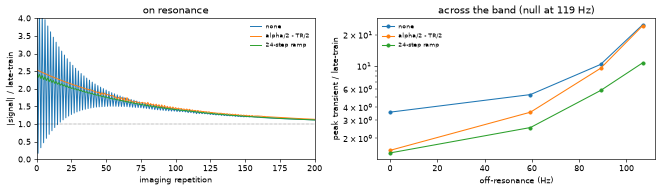

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 3.4))
for name, curve in CURVES.items():
    axes[0].plot(curve, lw=1.2, label=name)
axes[0].axhline(1.0, color='k', lw=0.6, ls=':')
axes[0].set(xlabel='imaging repetition', ylabel='|signal| / late-train',
            title='on resonance', xlim=(0, 200), ylim=(0, 4))
axes[0].legend(fontsize=7, frameon=False)

for name, (prep, stem) in CANDIDATES.items():
    first, k = BUILT[name]
    sweep = [peak_transient(DIAG_DIR / f'{stem}.seq', first, k, df=o)[0]
             for o in offsets]
    axes[1].plot(offsets, sweep, 'o-', lw=1.3, ms=4, label=name)
axes[1].set(xlabel='off-resonance (Hz)', ylabel='peak transient / late-train',
            title=f'across the band (null at {NULL_HZ:.0f} Hz)', yscale='log')
axes[1].legend(fontsize=7, frameon=False)
fig.tight_layout()

In [6]:
print('B1 robustness at the passband centre, same metric:')
print(f'{"preparation":18s}' + ''.join(f'{f"B1 x{b:.2f}":>11s}' for b in (0.9, 1.0, 1.1)))
for name, (prep, stem) in CANDIDATES.items():
    cells = []
    for b1 in (0.9, 1.0, 1.1):
        path = DIAG_DIR / f'{stem}_b1{int(b1 * 100)}.seq'
        first, k = transient_file(path, prep, b1=b1)
        cells.append(f'{peak_transient(path, first, k)[0]:11.2f}')
    print(f'{name:18s}' + ''.join(cells))

B1 robustness at the passband centre, same metric:
preparation          B1 x0.90   B1 x1.00   B1 x1.10


none                     3.10       3.59       4.16


/var/folders/16/qs6slfs1615_9cf889mc198c0000gn/T/ipykernel_42803/3086100621.py:36: SeqCraftWarning: 1 same-axis gradient merge: transient.alpha_over_2.Excitation (axis z)
  sc.compile(out, opts, name=path.stem).write(str(path))


alpha/2 - TR/2           1.23       1.53       1.89


24-step ramp             1.17       1.45       1.77


### How long a ramp

`01` ships 24 steps. That number comes from here: lengthening the ramp keeps improving the
band-edge transient with clearly diminishing returns, and the cost is repetitions that acquire
nothing.

ramp steps        0 Hz    107 Hz   cost (reps)


8                 1.69     20.30             8


16                1.53     15.86            16


24                1.45     10.80            24


32                1.39      9.90            32


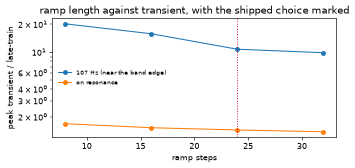

In [7]:
RAMP_SWEEP = (8, 16, 24, 32)
edge = 0.9 * NULL_HZ
print(f'{"ramp steps":12s}{"0 Hz":>10s}{f"{edge:.0f} Hz":>10s}{"cost (reps)":>14s}')
ramp_sweep = {}
for n in RAMP_SWEEP:
    path = DIAG_DIR / f'prep_ramp{n}.seq'
    first, k = transient_file(path, n)
    on = peak_transient(path, first, k)[0]
    off = peak_transient(path, first, k, df=edge)[0]
    ramp_sweep[n] = (on, off)
    print(f'{n:<12d}{on:10.2f}{off:10.2f}{n:14d}')

fig, ax = plt.subplots(figsize=(6.0, 3.0))
ax.plot(RAMP_SWEEP, [ramp_sweep[n][1] for n in RAMP_SWEEP], 'o-', lw=1.3, ms=5,
        label=f'{edge:.0f} Hz (near the band edge)')
ax.plot(RAMP_SWEEP, [ramp_sweep[n][0] for n in RAMP_SWEEP], 'o-', lw=1.3, ms=5,
        label='on resonance')
ax.axvline(RAMP_STEPS, color='crimson', ls=':', lw=1.2)
ax.set(xlabel='ramp steps', ylabel='peak transient / late-train', yscale='log',
       title='ramp length against transient, with the shipped choice marked')
ax.legend(fontsize=8, frameon=False)
fig.tight_layout()

### What that settles

**On resonance the two schemes are equivalent, and across the band they are not.** The `alpha/2`
pulse holds its advantage near the passband centre and loses it toward the edge; the ramp degrades
more slowly. That is the behaviour Hargreaves predicts for a non-selective half-angle pulse, and it
is the reason `01` ships the ramp.

**B1 does not separate them.** Both stay close to their nominal behaviour over `+-10%`, because in
both schemes every preparation pulse scales with the same B1 as the imaging pulses.

What neither of them does is change the decay rate. The curves on the left all approach the same
asymptote on the same timescale -- the eigenvalue from the previous section -- they simply start
closer to or further from it.

**CSF is excluded from any "repetitions to settle" claim here.** Its eigenvalue implies about 2500
repetitions to reach 5%, which is far beyond this train, so the tail of a 450-repetition CSF
simulation is not a steady state and must not be used as one.

## 2. What did `01` actually write?

`01` already asserts the artifact contract as it writes the files, and that check runs in
continuous integration. What is useful here is the acquisition *structure*: which views each file
visits, in what order, and where the centre of k-space falls relative to each ramp.

In [8]:
for stem in ('bssfp_3d', 'bssfp_3d_segmented',
             'bssfp_3d_validation', 'bssfp_3d_validation_segmented'):
    seq = pp.Sequence()
    seq.read(str(SEQ_DIR / f'{stem}.seq'))
    adcs = sum(1 for i in range(1, len(seq.block_events) + 1)
               if getattr(seq.get_block(i), 'adc', None) is not None)
    print(f'{stem:34s} {adcs:5d} readouts  {seq.duration()[0]:7.2f} s  '
          f'TR {float(seq.definitions["TR"]) * 1e3:.3f} ms')
print()
print(f'the two validation files are what gets reconstructed as a volume; the representative '
      f'pair is the same policy at {tuple(int(v) for v in nominal["matrix"])}, and section 4 '
      f'measures those')

bssfp_3d                            3072 readouts    13.03 s  TR 4.210 ms


bssfp_3d_segmented                  3072 readouts    24.89 s  TR 4.210 ms
bssfp_3d_validation                  256 readouts     1.18 s  TR 4.210 ms
bssfp_3d_validation_segmented        256 readouts     2.01 s  TR 4.210 ms

the two validation files are what gets reconstructed as a volume; the representative pair is the same policy at (192, 192, 16), and section 4 measures those


largest |ky| step between consecutive acquired views: 1
centre of k-space is view 144 of 256, 38 views into shot 3 of 5
01 measures the step over the whole RF train, including out of the ramp; this plot is
the acquired-view subset only.


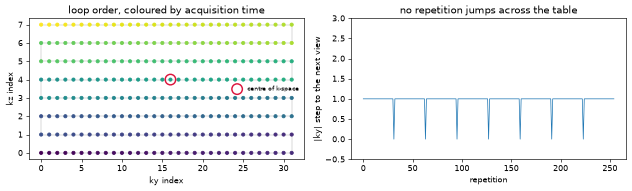

In [9]:
order = np.array(TABLE)
centre_at = TABLE.index((CENTER_LINE, CENTER_PARTITION))

fig, axes = plt.subplots(1, 2, figsize=(11.0, 3.4))
axes[0].plot(order[:, 0], order[:, 1], lw=0.6, color='0.7', zorder=1)
axes[0].scatter(order[:, 0], order[:, 1], c=np.arange(len(order)), cmap='viridis', s=16, zorder=2)
axes[0].scatter([CENTER_LINE], [CENTER_PARTITION], facecolors='none', edgecolors='crimson',
                s=170, lw=1.8, label='centre of k-space')
axes[0].set(xlabel='ky index', ylabel='kz index',
            title='loop order, coloured by acquisition time')
axes[0].legend(fontsize=7, frameon=False)

steps = np.abs(np.diff(order[:, 0]))
axes[1].plot(steps, lw=0.9)
axes[1].set(xlabel='repetition', ylabel='|ky| step to the next view',
            title='no repetition jumps across the table', ylim=(-0.5, max(3, steps.max() + 0.5)))
fig.tight_layout()

print(f'largest |ky| step between consecutive acquired views: {steps.max()}')
print(f'centre of k-space is view {centre_at} of {len(TABLE)}, '
      f'{centre_at % SHOT_VIEWS} views into shot {centre_at // SHOT_VIEWS + 1} '
      f'of {segments(len(TABLE))[0]}')
print('01 measures the step over the whole RF train, including out of the ramp; this plot is')
print('the acquired-view subset only.')

## 3. Does the continuous acquisition reconstruct correctly?

A 3D FFT of the sorted table. The three matrix dimensions are all different, so a `ky`/`kz` swap or
a transposed reconstruction changes the **shape** of the volume rather than producing a plausible
image.

sequence encoded FOV        300 x 300 x 96 mm
sequence excited slab       80 mm
phantom physical extent     192 x 192 x 96 mm
phantom matrix              (48, 32, 8)
simulation voxel            4.0 x 6.0 x 12.0 mm
image pixel                 6.2 x 9.4 x 12.0 mm



volume (48, 32, 8), peak at (np.int64(21), np.int64(13), np.int64(4))


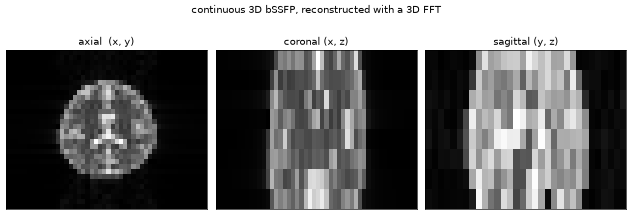

In [10]:
def reconstruct(rows):
    '''Sort repetitions into (kx, ky, kz) and take the 3D FFT.

    The table's indices are zero-based with DC at `matrix // 2`, which is the order `ifftshift`
    expects -- the centre convention the modules use is the one this assumes.
    '''
    cube = np.zeros((NX, NY, NZ), dtype=complex)
    for row, (line, partition) in enumerate(TABLE):
        cube[:, line, partition] = rows[row]
    return cube, np.fft.fftshift(np.fft.ifftn(np.fft.ifftshift(cube)))


def three_planes(volume, title):
    fig, axes = plt.subplots(1, 3, figsize=(11.0, 3.6))
    for ax, (name, plane) in zip(axes, (
            ('axial  (x, y)', volume[:, :, NZ // 2].T),
            ('coronal (x, z)', volume[:, NY // 2, :].T),
            ('sagittal (y, z)', volume[NX // 2, :, :].T))):
        ax.imshow(plane, cmap='gray', origin='lower', aspect='auto')
        ax.set(title=name, xticks=[], yticks=[])
    fig.suptitle(title, y=1.02)
    fig.tight_layout()
    return fig


if BRAIN_IMAGES:
    # `slab_3d`, not `slab`: the 2D helper returns NZ *native* slices, which at NZ = 8 is 12 mm
    # of anatomy inside a sequence that encodes 96 mm.  This one covers the encoded extent and
    # samples it at NZ voxels, which is a deliberately coarse phantom and a correct one.
    brain = ph.slab_3d(matrix=(NX, NY, NZ), z_extent_mm=FOV_MM[2], n_coils=0)
    ex = ph.extent_mm(brain)
    print(f'sequence encoded FOV        {FOV_MM[0]:.0f} x {FOV_MM[1]:.0f} x {FOV_MM[2]:.0f} mm')
    print(f'sequence excited slab       {SLAB_MM:.0f} mm')
    print(f'phantom physical extent     {ex[0]:.0f} x {ex[1]:.0f} x {ex[2]:.0f} mm')
    print(f'phantom matrix              {tuple(brain.PD.shape)}')
    print(f'simulation voxel            {ex[0] / NX:.1f} x {ex[1] / NY:.1f} x {ex[2] / NZ:.1f} mm')
    print(f'image pixel                 {FOV_MM[0] / NX:.1f} x {FOV_MM[1] / NY:.1f} x '
          f'{FOV_MM[2] / NZ:.1f} mm')

    assert abs(ex[2] - FOV_MM[2]) < 1.0, 'the phantom must span the encoded z extent'
    assert ex[0] <= FOV_MM[0] + 1 and ex[1] <= FOV_MM[1] + 1, 'and must fit inside the FOV'
    assert SLAB_MM < ex[2], 'the excited slab must sit inside the encoded extent'

    rows_cont = simulate(SEQ_DIR / 'bssfp_3d_validation.seq', brain.build())
    k_cont, vol_cont = reconstruct(rows_cont)
    three_planes(np.abs(vol_cont), 'continuous 3D bSSFP, reconstructed with a 3D FFT')
    print()
    print(f'volume {vol_cont.shape}, peak at '
          f'{np.unravel_index(np.argmax(np.abs(vol_cont)), vol_cont.shape)}')
else:
    print('BRAIN_IMAGES is off -- skipping the volume simulations')

The volume is `(48, 32, 8)`: readout, phase encode, partition. The sagittal plane is `32 x 8` and
visibly coarse along `z`, which is the geometry this reduced protocol asked for rather than an
artifact -- the representative protocol encodes the same slab with 16 partitions over a finer
in-plane matrix.

**This is what the reduced protocol is for**: geometry, orientation and the reconstruction itself.
The transient and ordering physics in the next section is measured on the representative files
instead, because a point-object history of those is cheap and the surrogate would be answering a
question about a different acquisition.

## 4. Segmentation, and the catalyzation it comes with

### Why segment at all

Not to shorten the acquisition -- the catalyzation below is pure overhead on top of it.
Segmentation exists because an acquisition sometimes **has to fit into repeated short temporal
windows**. Morita et al. (2008) give the reason in the literature's own terms: k-space segmentation
is "utilized for acquiring electrocardiogram (ECG) gating images in a short period of time in the
cardiovascular area". Cardiac cine is the canonical case -- only part of a cardiac phase's data
fits in one heartbeat, so a frame is assembled across heartbeats -- and ECG-gated coronary imaging,
breath-held abdominal work and magnetisation-prepared acquisitions have the same shape.

### What that introduces, and what the acquisition does about it

Every interruption leaves the magnetisation somewhere other than the periodic state. Morita's own
description of a segmented trueFISP with no dummy pulse is that the delay between shots was
"equivalent to a time of 28 RF pulses, which split the steady state".

So the acquisition `01` writes **catalyzes every segment**, including the first:

```text
segment 0     ramp up  ->  acquire 53 views
              recovery
segment 1     ramp up  ->  acquire 53 views
              recovery
segment 2     ramp up  ->  acquire 53 views
              ...
```

The continuous acquisition is the same policy with one segment, and the same ramp. That is the
point worth taking away from this notebook:

> **Segmentation is not inserting gaps into a continuous sequence.** The catalyzation policy is
> part of the acquisition definition, not a repair applied to it afterwards.

The ramp is the one Section 1 already chose on evidence -- 24 linear steps, which beat
`alpha/2 - TR/2` toward the band edge and tied with it on resonance. The same ramp serves both
positions it appears in, and they are not quite the same problem:

> **Initial catalyzation** starts the train from equilibrium. **Segment catalyzation** starts from
> the magnetisation left after an inter-shot gap.

One ramp length is used for both, as an explicit acquisition choice rather than a claim that 24 is
optimal for either. The teaching point is that **every independently interrupted imaging segment
needs an explicit catalyzation policy** -- not that this notebook has found the universally correct
number of catalyzation pulses.

### What it costs

Catalyzation repetitions acquire nothing. In a cardiac-gated acquisition the window length is
fixed by physiology, so every one of them is a view not collected.

In [11]:
shots, breaks, prep = segments(len(REP_TABLE))
print(f'{"":26s}{"shots":>7s}{"breaks":>8s}{"acquired":>10s}{"catalyze":>10s}{"overhead":>10s}')
print(f'{"continuous":26s}{1:7d}{0:8d}{len(REP_TABLE):10d}{RAMP_STEPS:10d}'
      f'{RAMP_STEPS / len(REP_TABLE) * 100:9.1f}%')
print(f'{f"segmented, {SHOT_VIEWS}-view shots":26s}{shots:7d}{breaks:8d}{len(REP_TABLE):10d}'
      f'{prep:10d}{prep / len(REP_TABLE) * 100:9.1f}%')
print()
print(f'a shot count and a break count are different numbers: {shots} segments, {breaks} '
      f'interruptions')
print(f'the catalyzation scales with the segments, so it is {shots}x the ramp, not {breaks}x')
print(f'in time: {prep * TR_S:.2f} s of catalyzation against {len(REP_TABLE) * TR_S:.2f} s of '
      f'acquisition, plus {breaks * RECOVERY_S:.2f} s of recovery')

                            shots  breaks  acquired  catalyze  overhead
continuous                      1       0      3072        24      0.8%
segmented, 53-view shots       58      57      3072      1392     45.3%

a shot count and a break count are different numbers: 58 segments, 57 interruptions
the catalyzation scales with the segments, so it is 58x the ramp, not 57x
in time: 5.86 s of catalyzation against 12.93 s of acquisition, plus 6.10 s of recovery


### What the interruption leaves behind, measured

Two quantities, and they are not the same thing. The first is what the acquisition *samples*; the
second is what a reader *sees*. Keeping them apart is the whole reason this section exists.

```text
per-view echo-magnitude      |echo| of each acquired repetition, against a small box at the
departure                    origin, whose transform is verified effectively flat over the sampled
                             table below -- so any variation across repetitions belongs to the
                             acquisition rather than the object.
                             This is the magnitude of one sampled echo -- NOT the magnetisation
                             vector, and not a statement about its distance from steady state.

point response               the reconstruction of that point.  Depends additionally on WHERE in
                             the table the modulated views fall, and on phase, neither of which a
                             per-view magnitude carries.
```

Both need an object whose own Fourier envelope is effectively flat across the sampled table, or its
transform is read as the acquisition's. A box is finite, so that is checked rather than assumed.

In [12]:
POINT_MM = 0.1
kmax = np.array([(REP_MATRIX[i] // 2) / (FOV_MM[i] * 1e-3) for i in range(3)])
envelope = float(np.prod(np.sinc(kmax * POINT_MM * 1e-3)))
print(f'|k|max per axis: ' + ', '.join(f'{v:.0f}' for v in kmax) + ' 1/m')
print(f'a {POINT_MM} mm box first nulls at {1 / (POINT_MM * 1e-3):.0f} 1/m')
print(f'its envelope at the far corner of the sampled table: {envelope:.4f}')
assert envelope > 0.99, 'the point object is not flat enough to call its k-space the acquisition'
print(f'-> verified effectively flat over the sampled table, so what is measured is the '
      f'acquisition')
print(f'   a 1 mm box would fall to {float(np.prod(np.sinc(kmax * 1e-3))):.2f} there, and would '
      f'report its own transform')

|k|max per axis: 320, 320, 83 1/m
a 0.1 mm box first nulls at 10000 1/m
its envelope at the far corner of the sampled table: 0.9965
-> verified effectively flat over the sampled table, so what is measured is the acquisition
   a 1 mm box would fall to 0.70 there, and would report its own transform


In [13]:
REP_NX, REP_NY, REP_NZ = REP_MATRIX
rep_kernel = sc.modules.bSSFP3DTR(
    opts=opts, fov_mm=FOV_MM, matrix=REP_MATRIX, slab_thickness_mm=SLAB_MM, flip_deg=FLIP_DEG,
    bandwidth_hz_px=BANDWIDTH_HZ_PX, rf_duration_s=RF_DURATION_S)
REP_ECHO = int(rep_kernel.ro.echo_sample(0))


def point(df=0.0, size_mm=POINT_MM, tissue='white matter'):
    return mr0.CustomVoxelPhantom(
        pos=[[0.0, 0.0, 0.0]], PD=1.0, D=0.0, T2dash=1e3, B0=float(df),
        voxel_size=size_mm * 1e-3, voxel_shape='box', **TISSUES[tissue],
    ).build()


def echo_magnitudes(path, df=0.0, tissue='white matter', samples=None, states=200):
    '''|echo| for every acquired repetition of one written train.'''
    rows = simulate_wide(path, point(df, tissue=tissue),
                         REP_NX if samples is None else samples, states=states)
    return np.abs(rows[:, REP_ECHO if samples is None else ECHO])


def point_response(path, df=0.0, states=200):
    '''The reconstructed point: the y profile through it, normalised to its peak.'''
    rows = simulate_wide(path, point(df), REP_NX, states=states)
    cube = np.zeros((REP_NX, REP_NY, REP_NZ), dtype=complex)
    for row, (line, partition) in enumerate(REP_TABLE):
        cube[:, line, partition] = rows[row]
    image = np.abs(np.fft.fftshift(np.fft.ifftn(np.fft.ifftshift(cube))))
    prof = image[REP_NX // 2, :, REP_NZ // 2]
    return prof / prof.max()


def far_response(prof):
    '''Summed and largest normalised magnitude away from the point itself.'''
    centre = len(prof) // 2
    far = np.array([prof[i] for i in range(len(prof)) if abs(i - centre) > 1])
    return far.sum(), far.max()


CASES = {'continuous': 'bssfp_3d', 'segmented, catalyzed': 'bssfp_3d_segmented'}
ECHOES, PROFILE = {}, {}
print(f'{"":24s}{"-- echo magnitude --":>26s}{"-- point response --":>24s}')
print(f'{"acquisition":24s}{"min/median":>13s}{"rms dev":>13s}{"far sum":>13s}{"max far":>11s}')
for label, stem in CASES.items():
    e = ECHOES[label] = echo_magnitudes(SEQ_DIR / f'{stem}.seq')
    level = np.median(e)
    PROFILE[label] = p = point_response(SEQ_DIR / f'{stem}.seq')
    fs, fm = far_response(p)
    print(f'{label:24s}{e.min() / level:13.3f}{np.sqrt(np.mean((e / level - 1) ** 2)):13.4f}'
          f'{fs:13.3f}{fm:11.4f}')

#: Both trains open from equilibrium with the same ramp, so the whole-train rms mixes that one
#: transient with whatever else happens.  Dropping the first two segments' worth separates them.
after = 2 * SHOT_VIEWS
print()
print(f'rms over the first {after} acquired views, and over everything after them:')
for label, e in ECHOES.items():
    level = np.median(e)
    head = np.sqrt(np.mean((e[:after] / level - 1) ** 2))
    rest = np.sqrt(np.mean((e[after:] / level - 1) ** 2))
    print(f'{label:24s} opening {head:.4f}   remainder {rest:.4f}')

                              -- echo magnitude --    -- point response --
acquisition                min/median      rms dev      far sum    max far


continuous                      0.998       0.1641        0.100     0.0055


segmented, catalyzed            0.932       0.1021        0.128     0.0049

rms over the first 106 acquired views, and over everything after them:
continuous               opening 0.8496   remainder 0.0456
segmented, catalyzed     opening 0.5001   remainder 0.0432


In [14]:
#: Every number here rests on 200 coherence states being enough for this train and this tissue.
#: That is an assumption about the simulator, not about the acquisition, so it is checked on the
#: harder of the two cases rather than assumed.  The tissue sweep below shows it does not always
#: hold.
_f200 = far_response(PROFILE['segmented, catalyzed'])[0]
_f400 = far_response(point_response(SEQ_DIR / 'bssfp_3d_segmented.seq', states=400))[0]
print(f'summed far response at 200 states {_f200:.4f}, at 400 states {_f400:.4f} '
      f'-- {abs(_f400 - _f200) / _f200:.2%} apart')
assert abs(_f400 - _f200) / _f200 < 0.02, '200 states is not enough for this measurement'

summed far response at 200 states 0.1282, at 400 states 0.1282 -- 0.00% apart


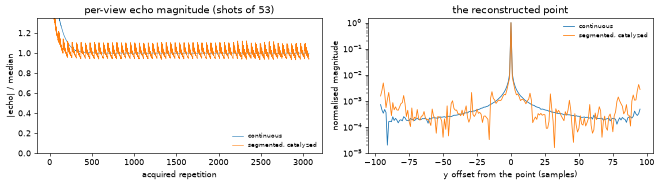

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 3.3))
for label, e in ECHOES.items():
    axes[0].plot(e / np.median(e), lw=0.7, label=label)
axes[0].set(xlabel='acquired repetition', ylabel='|echo| / median',
            title=f'per-view echo magnitude (shots of {SHOT_VIEWS})', ylim=(0, 1.35))
axes[0].legend(fontsize=7, frameon=False, loc='lower right')

for label, p in PROFILE.items():
    axes[1].plot(np.arange(REP_NY) - REP_NY // 2, p, lw=1.0, label=label)
axes[1].set(xlabel='y offset from the point (samples)', ylabel='normalised magnitude',
            yscale='log', ylim=(1e-5, 1.5), title='the reconstructed point')
axes[1].legend(fontsize=7, frameon=False)
fig.tight_layout()

### What that says

Two things, and the second is the one worth keeping.

The segmented acquisition pays for its interruptions: its per-view echo magnitude dips where the
continuous train's does not, and its summed far response is higher. That is the cost, and it is
small -- the acquisition is interrupted 57 times and the reconstructed point response grows by
roughly a quarter.

The whole-train rms, though, comes out *lower* for the segmented train than the continuous one,
which is emphatically not a claim that interrupting helps. The split says why. Both open from
equilibrium with the same ramp, and that one transient dominates the figure: drop the first two
segments' worth of views and the continuous train's rms falls from 0.164 to 0.046. Do the same to
the segmented train and it falls to 0.043 -- **the same number, to within the noise, across 56
further interruptions**. (Its opening window reads lower too, because at 106 views that window
already contains one segment catalyzation.)

That is the result worth keeping, and it is the distinction above measured. After 107 ms the
magnetisation has relaxed from a *driven* state rather than returning to equilibrium, so **segment
catalyzation starts much closer to the periodic state than initial catalyzation does** -- and one
ramp sized for the harder of the two covers both comfortably.

And note what that leaves: the ongoing echo-magnitude modulation of the two trains is equal, and the
reconstructed point response is still about a quarter larger. The two measurements disagree in the
cleanest form yet -- what differs is not how much modulation there is, but where in the table it
lands and what phase it carries, neither of which a per-view magnitude reports.

### A failure mode worth naming, and not shipping

If acquisition resumed immediately after each interruption, the first views of every segment would
be acquired while the magnetisation was still far from the periodic state. Where those views fall
in the table would then decide how that transient appears in the image.

This is not hypothetical. Morita et al. compared centric and linear `(kx, ky)` orderings of exactly
such a sequence, and found different contrast from the same protocol: with no dummy pulse, "the
data of the k-space center of each shot with centric ordering was sampled from the first RF pulse,
while [that] with linear ordering was sampled after 26 RF pulses were excited".

That is a sound experiment, and a real clinical configuration. It is **not** a generic authoring
pattern, so this notebook describes it rather than shipping an under-prepared `.seq` alongside the
one a reader should copy.

### Where the segment boundaries land still matters

Catalyzation addresses the transient; it does not change the fact that the segment boundaries fall
*somewhere* in the table, and the view order decides where. `SHOT_VIEWS = 53` is Morita's reported
echo train length; 64 would divide this 192-line table exactly three times. The difference is worth
one measurement, as a sensitivity demonstration rather than a tuning parameter.

In [16]:
#: 01 owns the authoring; this rebuilds the same policy so the shot length can be varied.  The
#: guard below is what keeps the two from drifting: at 01's setting it must reproduce 01's file.
RAMP = [sc.modules.bSSFP3DTR(
            opts=opts, fov_mm=FOV_MM, matrix=REP_MATRIX, slab_thickness_mm=SLAB_MM,
            flip_deg=FLIP_DEG * (k + 1) / (RAMP_STEPS + 1), bandwidth_hz_px=BANDWIDTH_HZ_PX,
            rf_duration_s=RF_DURATION_S, tr_s=rep_kernel.tr_s)
        for k in range(RAMP_STEPS)]


def segmented_train(path, *, shot_views):
    '''01's acquisition policy, with the shot length as the free parameter.'''
    tree, at, n = sc.LogicBlock('sensitivity'), 0.0, 0
    for i, (line, partition) in enumerate(REP_TABLE):
        if i == 0 or i % shot_views == 0:
            if i > 0:
                at = sc.Raster(opts.grad_raster_time).ceil(at + RECOVERY_S)
            for rep in RAMP:
                tree.add(at, rep(line=line, partition=partition,
                                 phase_deg=PHASE_STEP * n, acquire=False))
                at, n = at + rep.tr_s, n + 1
        tree.add(at, rep_kernel(line=line, partition=partition, phase_deg=PHASE_STEP * n))
        at, n = at + rep_kernel.tr_s, n + 1
    sc.compile(tree, opts, name=path.stem).write(str(path))
    return path


def shape_of(path):
    seq = pp.Sequence()
    seq.read(str(path))
    adcs = sum(1 for i in range(1, len(seq.block_events) + 1)
               if getattr(seq.get_block(i), 'adc', None) is not None)
    return adcs, len(seq.block_events), round(seq.duration()[0], 6)


mine = shape_of(segmented_train(DIAG_DIR / 'check.seq', shot_views=SHOT_VIEWS))
theirs = shape_of(SEQ_DIR / 'bssfp_3d_segmented.seq')
assert mine == theirs, f'this builder has drifted from 01: {mine} != {theirs}'
print(f'builder reproduces 01 at {SHOT_VIEWS} views/shot: {mine[0]} readouts, '
      f'{mine[1]} blocks, {mine[2]:.3f} s')

builder reproduces 01 at 53 views/shot: 3072 readouts, 31305 blocks, 24.892 s


  shots of  192 / shot   min/median    rms dev    far sum   max far


        53        3.62        0.932     0.1021      0.128    0.0049


        64        3.00        0.931     0.1099      0.158    0.0084


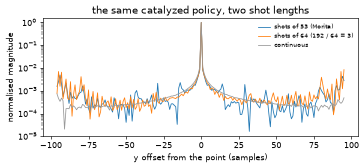

In [17]:
alt = segmented_train(DIAG_DIR / 'shot64.seq', shot_views=64)
print(f'{"shots of":>10s}{"192 / shot":>12s}{"min/median":>13s}{"rms dev":>11s}'
      f'{"far sum":>11s}{"max far":>10s}')
curves = {}
for n_views, path in ((SHOT_VIEWS, SEQ_DIR / 'bssfp_3d_segmented.seq'), (64, alt)):
    e = echo_magnitudes(path)
    level = np.median(e)
    prof = PROFILE['segmented, catalyzed'] if n_views == SHOT_VIEWS else point_response(path)
    curves[n_views] = prof
    fs, fm = far_response(prof)
    print(f'{n_views:>10d}{REP_MATRIX[1] / n_views:12.2f}{e.min() / level:13.3f}'
          f'{np.sqrt(np.mean((e / level - 1) ** 2)):11.4f}{fs:11.3f}{fm:10.4f}')

fig, ax = plt.subplots(figsize=(6.4, 3.0))
for n_views, prof in curves.items():
    ax.plot(np.arange(REP_NY) - REP_NY // 2, prof, lw=1.0,
            label=f'shots of {n_views}' + (' (192 / 64 = 3)' if n_views == 64 else ' (Morita)'))
ax.plot(np.arange(REP_NY) - REP_NY // 2, PROFILE['continuous'], lw=1.0, color='0.6',
        label='continuous')
ax.set(xlabel='y offset from the point (samples)', ylabel='normalised magnitude', yscale='log',
       ylim=(1e-5, 1.5), title='the same catalyzed policy, two shot lengths')
ax.legend(fontsize=7, frameon=False)
fig.tight_layout()

The per-view echo modulation is within 8% between the two, and the point responses are not: 64-view
shots give about a quarter more summed far response and about seventy percent more in the largest
single sample. A shot length that divides the phase-encode count repeats whatever modulation
survives at the same few `ky` positions, where it adds coherently; one that does not spreads it
across the table.

Both are modest here, and that is the catalyzation doing its job -- the boundaries still fall
somewhere, but there is much less left at them to be placed well or badly. The lesson is the
mapping, not either number --

> similar per-view modulation can produce quite different image structure, depending on where the
> segment boundaries fall in the phase-encode table.

-- and it is a reason to measure a segmented protocol rather than a parameter to tune. The shipped
shot length stays at Morita's 53 because that is what the literature specifies for this regime.

### Off-resonance

During the gap no RF is played, so off-resonance phase accrues freely for 107 ms -- about 25 TRs
worth -- while `T1` and `T2` relaxation run. Where the magnetisation has drifted to when
catalyzation resumes therefore depends on `Δf`, which is a reason to check the passband rather than
assume resonance is representative of it.

This sweep runs on the **validation** files, and that forces the metric to change. The reduced
protocol holds every variable the per-segment dynamics depends on fixed -- same TR, same 53-view
shots, same 107 ms recovery, same catalyzation -- but it is only 256 views long, so each segment's
ramp is a much larger fraction of the train. An absolute deviation there would mostly be measuring
the ramps. So the comparison is **differential**: the segmented train against the continuous one
view by view, at the same offset.

rms |echo| difference from the continuous train at the same offset, / its mean level
                                     0.00 band   0.25 band   0.50 band   0.75 band
segmented, catalyzed                    0.0746      0.0823      0.1217      0.2192
continuous mean |echo|, normalised      1.0000      0.9969      0.9378      0.6626
band edge (first null) at 119 Hz; the gap is 25 TRs of free precession


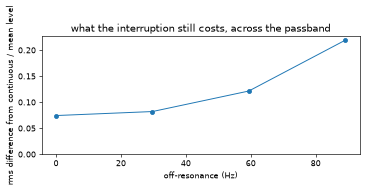

In [18]:
OFFSETS = [0.0, 0.25, 0.5, 0.75]


def departure(df=0.0, tissue='white matter', states=200):
    '''rms |echo| difference from the continuous train, over that train's mean level.'''
    base = echo_magnitudes(SEQ_DIR / 'bssfp_3d_validation.seq', df, tissue, SAMPLES, states)
    seg = echo_magnitudes(SEQ_DIR / 'bssfp_3d_validation_segmented.seq', df, tissue, SAMPLES,
                          states)
    return np.sqrt(np.mean((seg - base) ** 2)) / base.mean(), base.mean()


curve, level = [], []
for frac in OFFSETS:
    value, mean = departure(frac * NULL_HZ)
    curve.append(value)
    level.append(mean)
print('rms |echo| difference from the continuous train at the same offset, / its mean level')
print(f'{"":34s}' + ''.join(f'{f"{f:.2f} band":>12s}' for f in OFFSETS))
print(f'{"segmented, catalyzed":34s}' + ''.join(f'{v:12.4f}' for v in curve))
print(f'{"continuous mean |echo|, normalised":34s}'
      + ''.join(f'{v / level[0]:12.4f}' for v in level))
print(f'band edge (first null) at {NULL_HZ:.0f} Hz; the gap is '
      f'{RECOVERY_S / TR_S:.0f} TRs of free precession')

fig, ax = plt.subplots(figsize=(6.4, 3.0))
ax.plot([f * NULL_HZ for f in OFFSETS], curve, 'o-', lw=1.2, ms=5)
ax.set(xlabel='off-resonance (Hz)', ylabel='rms difference from continuous / mean level',
       title='what the interruption still costs, across the passband', ylim=(0, None))
fig.tight_layout()

The residual cost is not uniform across the passband: it roughly triples between resonance and
`0.75` of the way to the band edge, while the signal it is measured against falls to about
two-thirds. Nothing in the gap is refocused -- off-resonance phase accrues freely for 25 TRs' worth
of time -- and the further from resonance that is, the more the catalyzation has to undo. A
protocol that will be run off-resonance should not assume an on-resonance measurement of its
segmentation cost.

### Does any of this depend on tissue?

Everything above is white matter, and the volume below is not. Asking the question of a balanced
sequence means first asking whether the **simulation** can answer it: bSSFP keeps its coherence
pathways alive, a long `T2` keeps more of them alive for longer, and every number so far rests on a
state budget chosen for white matter. The budget is swept before the comparison is read.

In [19]:
BUDGETS = (200, 400, 800)
print(f'{"tissue":14s}{"T1 s":>6s}{"T2 s":>7s}  '
      + ''.join(f'{f"{s} states":>13s}' for s in BUDGETS) + '   verdict')
for tissue, props in TISSUES.items():
    seen = [departure(0.0, tissue, s)[0] for s in BUDGETS]
    drift = abs(seen[-1] - seen[-2]) / seen[-1]
    verdict = 'converged' if drift < 0.02 else f'STILL MOVING ({drift:.0%})'
    print(f'{tissue:14s}{props["T1"]:6.2f}{props["T2"]:7.3f}  '
          + ''.join(f'{v:13.4f}' for v in seen) + f'   {verdict}')
print()
print('the state budget is a property of T2 against TR, not of the acquisition under test, so a')
print('tissue that fails this is excluded rather than quoted')

tissue          T1 s   T2 s     200 states   400 states   800 states   verdict


white matter    0.83  0.080         0.0746       0.0746       0.0746   converged


grey matter     1.33  0.110         0.0627       0.0631       0.0631   converged


CSF             4.00  2.000         0.4369       0.4500       0.4615   STILL MOVING (3%)

the state budget is a property of T2 against TR, not of the acquisition under test, so a
tissue that fails this is excluded rather than quoted


### The segmented volume

Section 3 reconstructed the continuous acquisition. The same reduced protocol, segmented.

summed |difference| from the continuous volume: 13.2% of its signal

this is taken after reconstruction, so it carries phase and the position of each
residual in k-space -- neither of which the per-view magnitude above reports, and it
also contains the tissue the state-budget sweep could not price


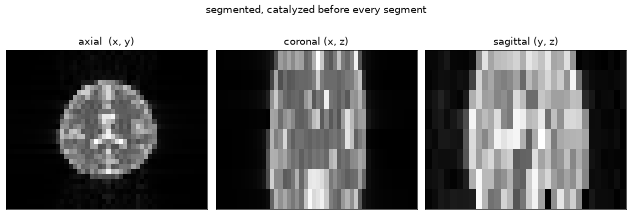

In [20]:
if BRAIN_IMAGES:
    volume = reconstruct(simulate(SEQ_DIR / 'bssfp_3d_validation_segmented.seq', brain.build()))[1]
    three_planes(np.abs(volume), 'segmented, catalyzed before every segment')
    rel = np.abs(np.abs(volume) - np.abs(vol_cont)).sum() / np.abs(vol_cont).sum()
    print(f'summed |difference| from the continuous volume: {rel * 100:.1f}% of its signal')
    print()
    print('this is taken after reconstruction, so it carries phase and the position of each')
    print('residual in k-space -- neither of which the per-view magnitude above reports, and it')
    print('also contains the tissue the state-budget sweep could not price')
else:
    print('BRAIN_IMAGES is off -- the point-object numbers above are the quantitative result')

### What still depends on the application

The point response along `y` is a point response, not a resolution metric: it says how much signal
from one location appears at other locations, and nothing about how finely two nearby objects can
be told apart. Nor is the per-view echo magnitude a statement about the magnetisation vector --
it is one sampled echo's amplitude, and the image depends on phase and on k-space position too.

What this section establishes is a shape, not a number to carry elsewhere:

```text
segment length         how many repetitions a segment holds against the transient decay length,
                       which is an eigenvalue of the repetition's transfer matrix
recovery duration      against T1 and T2, and the off-resonance phase accrued while no RF
                       constrains it
catalyzation design    which family, how long, at what encoding -- and how much of a fixed
                       imaging window it is acceptable to spend on it
view ordering          where the segment boundaries fall in the table, measured above
RF phase policy        whether the alternation continues across the gap or resets
```

The acquisition this notebook ships picks one point in that space: 53-view segments, 107 ms
recovery, a 24-step linear ramp before each, a `0/pi` alternation carried unbroken across the gap,
and a bidirectional sequential order over 192 lines.